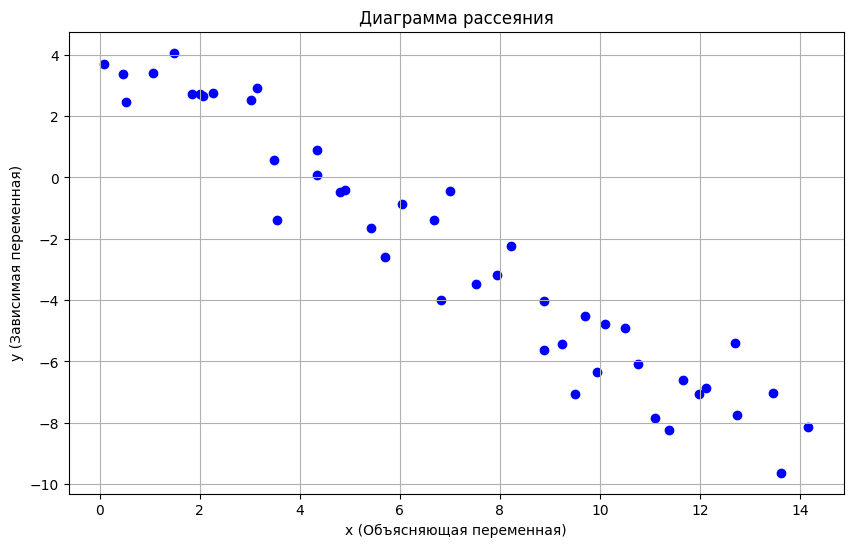


--- Результаты оценивания ---
Коэффициент наклона (beta_1_hat): -0.9411
Свободный член (beta_0_hat): 4.1779
Уравнение регрессии: y_hat = 4.1779 + -0.9411 * x


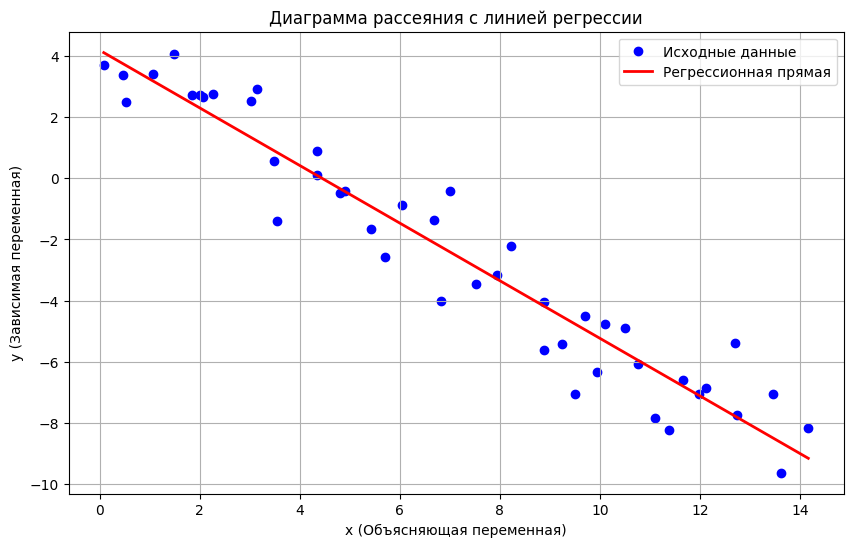


--- Таблица с прогнозами и остатками (фрагмент) ---
        x       y     y_hat         e        e2
0  0.0778  3.7089  4.104697 -0.395797  0.156656
1  0.4630  3.3843  3.742185 -0.357885  0.128081
2  0.5181  2.4759  3.690330 -1.214430  1.474840
3  1.0643  3.3936  3.176300  0.217300  0.047219
4  1.4781  4.0705  2.786872  1.283628  1.647702

--- Оценка ошибки ---
RSS (Остаточная сумма квадратов): 52.9577
s^2 (Оценка дисперсии): 1.2316
s (Стандартная ошибка регрессии): 1.1098

--- Доверительные интервалы (95%) ---
t_критическое: 2.0167
SE(beta_1): 0.0401, CI для beta_1: (-1.0220, -0.8602)
SE(beta_0): 0.3277, CI для beta_0: (3.5170, 4.8388)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# 3.1. Загрузка данных
# ==========================================
df = pd.read_csv('variant_4_data.csv')

# ==========================================
# 3.2. Диаграмма рассеяния
# ==========================================
plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], color='blue', label='Исходные данные')
plt.title('Диаграмма рассеяния')
plt.xlabel('x (Объясняющая переменная)')
plt.ylabel('y (Зависимая переменная)')
plt.grid(True)
plt.show()

# ==========================================
# 4.1 - 4.3. Оценивание коэффициентов
# ==========================================
n = len(df)
x_mean = df['x'].mean()
y_mean = df['y'].mean()

s_xx = np.sum((df['x'] - x_mean)**2)
s_xy = np.sum((df['x'] - x_mean) * (df['y'] - y_mean))

beta_1_hat = s_xy / s_xx
beta_0_hat = y_mean - beta_1_hat * x_mean

print(f"\n--- Результаты оценивания ---")
print(f"Коэффициент наклона (beta_1_hat): {beta_1_hat:.4f}")
print(f"Свободный член (beta_0_hat): {beta_0_hat:.4f}")
print(f"Уравнение регрессии: y_hat = {beta_0_hat:.4f} + {beta_1_hat:.4f} * x")

# ==========================================
# 3.4. Расчёт прогнозных значений и остатков
# ==========================================
df['y_hat'] = beta_0_hat + beta_1_hat * df['x']
df['e'] = df['y'] - df['y_hat']
df['e2'] = df['e']**2

plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], color='blue', label='Исходные данные')
plt.plot(df['x'], df['y_hat'], color='red', linewidth=2, label='Регрессионная прямая')
plt.title('Диаграмма рассеяния с линией регрессии')
plt.xlabel('x (Объясняющая переменная)')
plt.ylabel('y (Зависимая переменная)')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Таблица с прогнозами и остатками (фрагмент) ---")
print(df[['x', 'y', 'y_hat', 'e', 'e2']].head())

# ==========================================
# 4.5 - 4.6. Оценка дисперсии ошибки
# ==========================================
rss = df['e2'].sum()
s2 = rss / (n - 2)
s_error = np.sqrt(s2)

print(f"\n--- Оценка ошибки ---")
print(f"RSS (Остаточная сумма квадратов): {rss:.4f}")
print(f"s^2 (Оценка дисперсии): {s2:.4f}")
print(f"s (Стандартная ошибка регрессии): {s_error:.4f}")

# ==========================================
# 4.7 - 4.8. Доверительные интервалы для коэффициентов
# ==========================================
se_beta_1 = s_error / np.sqrt(s_xx)
se_beta_0 = s_error * np.sqrt(1/n + x_mean**2 / s_xx)

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, n - 2)

# Интервалы
b1_ci = (beta_1_hat - t_crit * se_beta_1, beta_1_hat + t_crit * se_beta_1)
b0_ci = (beta_0_hat - t_crit * se_beta_0, beta_0_hat + t_crit * se_beta_0)

print(f"\n--- Доверительные интервалы (95%) ---")
print(f"t_критическое: {t_crit:.4f}")
print(f"SE(beta_1): {se_beta_1:.4f}, CI для beta_1: ({b1_ci[0]:.4f}, {b1_ci[1]:.4f})")
print(f"SE(beta_0): {se_beta_0:.4f}, CI для beta_0: ({b0_ci[0]:.4f}, {b0_ci[1]:.4f})")

--- Исходные данные (первые 5 строк) ---
   i       x       y
0  1  0.0778  3.7089
1  2  0.4630  3.3843
2  3  0.5181  2.4759
3  4  1.0643  3.3936
4  5  1.4781  4.0705


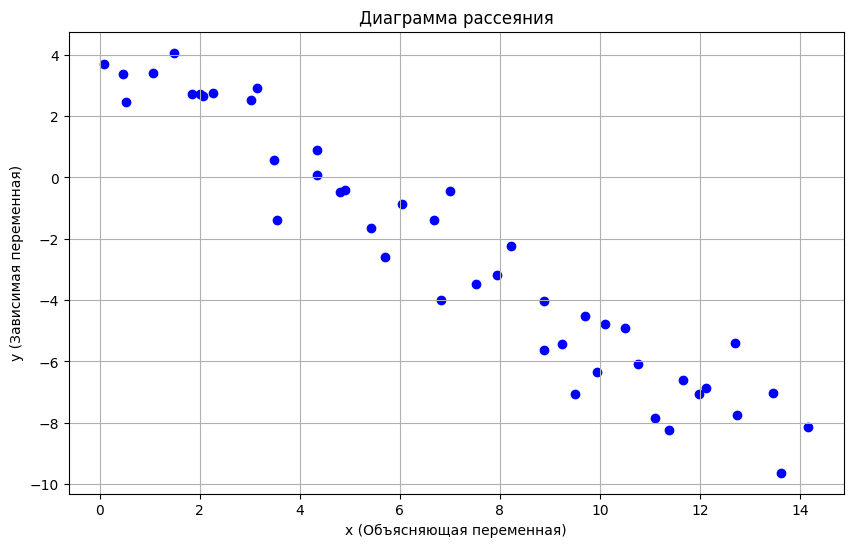


--- Результаты оценивания ---
Среднее x: 7.0485
Среднее y: -2.4554
Коэффициент наклона (beta_1_hat): -0.9411
Свободный член (beta_0_hat): 4.1779
Уравнение регрессии: y_hat = 4.1779 + -0.9411 * x

--- Таблица с прогнозами и остатками (фрагмент) ---
        x       y     y_hat         e        e2
0  0.0778  3.7089  4.104697 -0.395797  0.156656
1  0.4630  3.3843  3.742185 -0.357885  0.128081
2  0.5181  2.4759  3.690330 -1.214430  1.474840
3  1.0643  3.3936  3.176300  0.217300  0.047219
4  1.4781  4.0705  2.786872  1.283628  1.647702

--- Оценка ошибки ---
RSS (Остаточная сумма квадратов): 52.9577
s^2 (Оценка дисперсии): 1.2316
s (Стандартная ошибка регрессии): 1.1098

--- Доверительные интервалы (95%) ---
t_критическое: 2.0167
SE(beta_1): 0.0401, CI для beta_1: (-1.0220, -0.8602)
SE(beta_0): 0.3277, CI для beta_0: (3.5170, 4.8388)

Коэффициент детерминации R^2: 0.9275


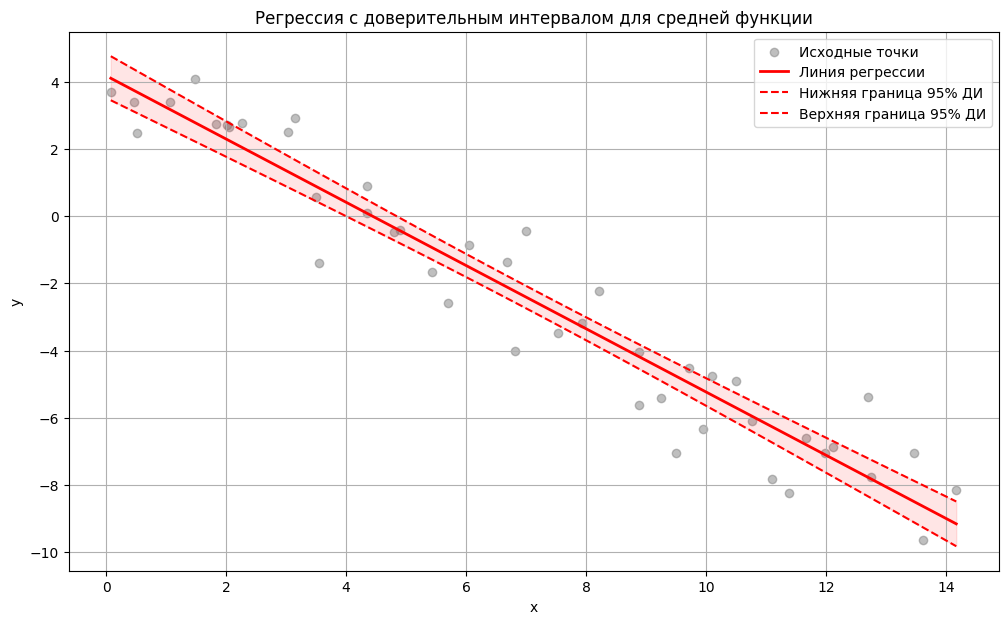

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# 3.1. Загрузка данных
# ==========================================
df = pd.read_csv('variant_4_data.csv')


print("--- Исходные данные (первые 5 строк) ---")
print(df.head())

# ==========================================
# 3.2. Диаграмма рассеяния
# ==========================================
plt.figure(figsize=(10, 6))
plt.scatter(df['x'], df['y'], color='blue', label='Исходные данные')
plt.title('Диаграмма рассеяния')
plt.xlabel('x (Объясняющая переменная)')
plt.ylabel('y (Зависимая переменная)')
plt.grid(True)
plt.show()

# ==========================================
# 4.1 - 4.3. Оценивание коэффициентов
# ==========================================
n = len(df)
x_mean = df['x'].mean()
y_mean = df['y'].mean()

s_xx = np.sum((df['x'] - x_mean)**2)
s_xy = np.sum((df['x'] - x_mean) * (df['y'] - y_mean))

beta_1_hat = s_xy / s_xx
beta_0_hat = y_mean - beta_1_hat * x_mean

print(f"\n--- Результаты оценивания ---")
print(f"Среднее x: {x_mean:.4f}")
print(f"Среднее y: {y_mean:.4f}")
print(f"Коэффициент наклона (beta_1_hat): {beta_1_hat:.4f}")
print(f"Свободный член (beta_0_hat): {beta_0_hat:.4f}")
print(f"Уравнение регрессии: y_hat = {beta_0_hat:.4f} + {beta_1_hat:.4f} * x")

# ==========================================
# 3.4. Расчёт прогнозных значений и остатков
# ==========================================
df['y_hat'] = beta_0_hat + beta_1_hat * df['x']
df['e'] = df['y'] - df['y_hat']
df['e2'] = df['e']**2

print("\n--- Таблица с прогнозами и остатками (фрагмент) ---")
print(df[['x', 'y', 'y_hat', 'e', 'e2']].head())

# ==========================================
# 4.5 - 4.6. Оценка дисперсии ошибки
# ==========================================
rss = df['e2'].sum()
s2 = rss / (n - 2)
s_error = np.sqrt(s2)

print(f"\n--- Оценка ошибки ---")
print(f"RSS (Остаточная сумма квадратов): {rss:.4f}")
print(f"s^2 (Оценка дисперсии): {s2:.4f}")
print(f"s (Стандартная ошибка регрессии): {s_error:.4f}")

# ==========================================
# 4.7 - 4.8. Доверительные интервалы для коэффициентов
# ==========================================
se_beta_1 = s_error / np.sqrt(s_xx)
se_beta_0 = s_error * np.sqrt(1/n + x_mean**2 / s_xx)

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, n - 2)

# Интервалы
b1_ci = (beta_1_hat - t_crit * se_beta_1, beta_1_hat + t_crit * se_beta_1)
b0_ci = (beta_0_hat - t_crit * se_beta_0, beta_0_hat + t_crit * se_beta_0)

print(f"\n--- Доверительные интервалы (95%) ---")
print(f"t_критическое: {t_crit:.4f}")
print(f"SE(beta_1): {se_beta_1:.4f}, CI для beta_1: ({b1_ci[0]:.4f}, {b1_ci[1]:.4f})")
print(f"SE(beta_0): {se_beta_0:.4f}, CI для beta_0: ({b0_ci[0]:.4f}, {b0_ci[1]:.4f})")

# ==========================================
# 4.10. Коэффициент детерминации R^2
# ==========================================
tss = np.sum((df['y'] - y_mean)**2)
r_squared = 1 - rss / tss
print(f"\nКоэффициент детерминации R^2: {r_squared:.4f}")

# ==========================================
# 4.9 & 5. Построение итогового графика
# ==========================================
# Создаем сетку значений x для плавных линий границ
x_range = np.linspace(df['x'].min(), df['x'].max(), 100)
y_range_hat = beta_0_hat + beta_1_hat * x_range

# Стандартная ошибка для функции регрессии
se_y_hat = s_error * np.sqrt(1/n + (x_range - x_mean)**2 / s_xx)

# Границы интервала
lower_bound = y_range_hat - t_crit * se_y_hat
upper_bound = y_range_hat + t_crit * se_y_hat

plt.figure(figsize=(12, 7))
plt.scatter(df['x'], df['y'], color='gray', alpha=0.5, label='Исходные точки')
plt.plot(x_range, y_range_hat, color='red', linewidth=2, label='Линия регрессии')
plt.plot(x_range, lower_bound, 'r--', label='Нижняя граница 95% ДИ')
plt.plot(x_range, upper_bound, 'r--', label='Верхняя граница 95% ДИ')

plt.fill_between(x_range, lower_bound, upper_bound, color='red', alpha=0.1)

plt.title('Регрессия с доверительным интервалом для средней функции')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

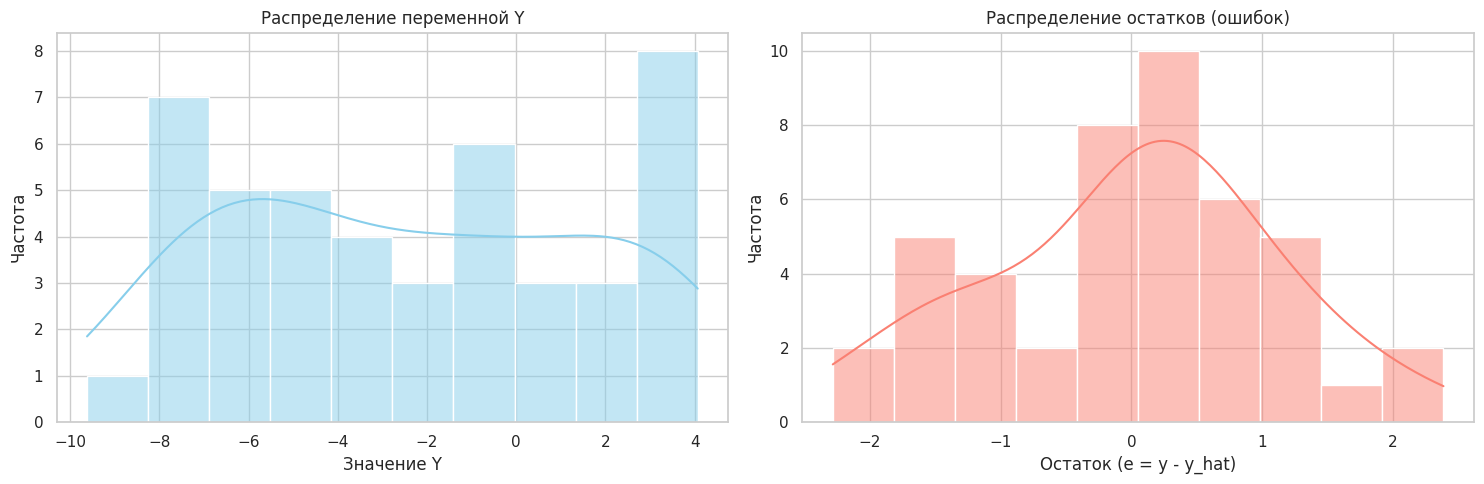

Среднее значение остатков: 0.0000000000
(В хорошей модели оно должно быть практически равно 0)


In [13]:
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['y'], kde=True, color='skyblue', ax=axes[0], bins=10)
axes[0].set_title('Распределение переменной Y')
axes[0].set_xlabel('Значение Y')
axes[0].set_ylabel('Частота')

sns.histplot(df['e'], kde=True, color='salmon', ax=axes[1], bins=10)
axes[1].set_title('Распределение остатков (ошибок)')
axes[1].set_xlabel('Остаток (e = y - y_hat)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print(f"Среднее значение остатков: {df['e'].mean():.10f}")
print("(В хорошей модели оно должно быть практически равно 0)")

<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3395/771808690.py:12: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Прогнозные значения ($\hat{y}$)', fontsize=12)


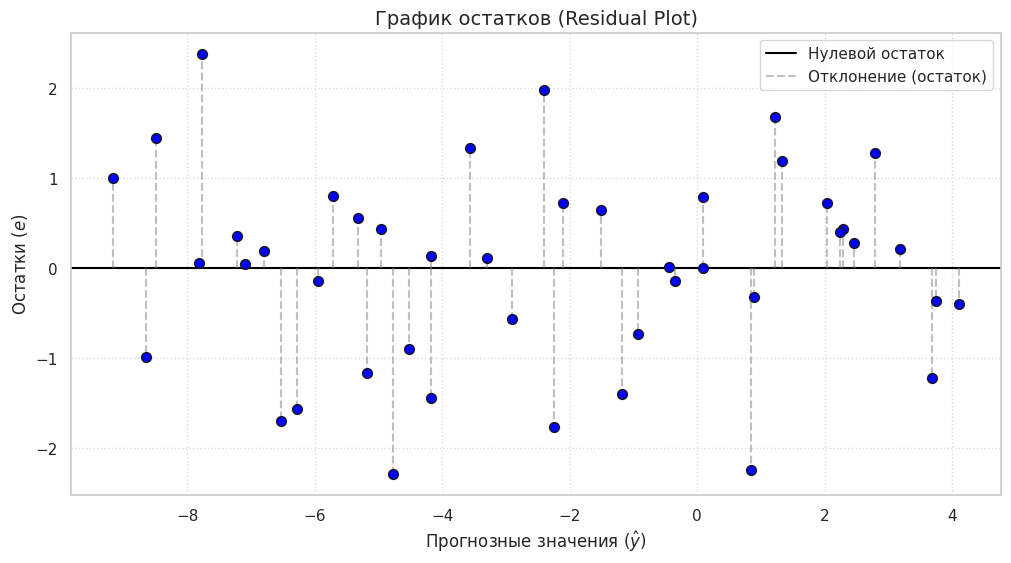

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5, label='Нулевой остаток')

plt.vlines(df['y_hat'], 0, df['e'], colors='gray', linestyles='--', alpha=0.5, label='Отклонение (остаток)')

plt.scatter(df['y_hat'], df['e'], color='blue', edgecolor='k', s=50, zorder=3)

plt.title('График остатков (Residual Plot)', fontsize=14)
plt.xlabel('Прогнозные значения ($\hat{y}$)', fontsize=12)
plt.ylabel('Остатки ($e$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

plt.show()